demo notebook into a **side-by-side visual comparison** of BLIP vs Scene Graph captions across multiple images. This will help you evaluate caption quality, semantic richness, and alignment with CLIP embeddings.

## 🧪 Multi-Image Caption Comparison Notebook

### 📁 Step 0: Prepare Your Dataset

Organize a small test set (e.g., 3–5 images) in a folder:

```bash
test_images/
├── img1.jpg
├── img2.jpg
├── img3.jpg
```

---

### 🧱 Notebook Structure

We'll loop through each image and for each one:

1. Display the image
2. Generate BLIP caption
3. Generate Scene Graph caption (via YOLO + spatial relations)
4. Compute CLIP similarity for both
5. Visualize everything side-by-side

---

In [1]:
# Setup

%pip install ultralytics transformers torch torchvision matplotlib networkx

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Then import everything:

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
from transformers import BlipProcessor, BlipForConditionalGeneration, CLIPProcessor, CLIPModel
import networkx as nx

# 🔄 Step 2: Define Core Functions

In [24]:
# BLIP Captioning

blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base",use_fast=True)
blip_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

def get_blip_caption(image):
    inputs = blip_processor(image, return_tensors="pt")
    caption_ids = blip_model.generate(**inputs, max_new_tokens=50)
    return blip_processor.decode(caption_ids[0], skip_special_tokens=True)

In [25]:
# YOLO + Scene Graph Captioning

yolo = YOLO("yolov8n.pt")

def get_scene_graph_caption(image_path):
    results = yolo(image_path)
    boxes = results[0].boxes.xyxy.cpu().numpy()
    labels = results[0].boxes.cls.cpu().numpy()
    names = results[0].names

    def get_relation(boxA, boxB):
        xa, ya, xa2, ya2 = boxA
        xb, yb, xb2, yb2 = boxB
        if ya2 < yb: return "above"
        elif ya > yb2: return "below"
        elif xa2 < xb: return "left of"
        elif xa > xb2: return "right of"
        else: return "near"

    relations = []
    for i in range(len(boxes)):
        for j in range(len(boxes)):
            if i != j:
                rel = get_relation(boxes[i], boxes[j])
                relations.append((names[int(labels[i])], rel, names[int(labels[j])]))

    caption = ", ".join([f"{a} {r} {b}" for a, r, b in relations])
    return caption

In [26]:
# CLIP Similarity

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

def get_clip_similarity(image, caption):
    inputs = clip_processor(text=[caption], images=image, return_tensors="pt", padding=True)
    outputs = clip_model(**inputs)
    img_emb = outputs.image_embeds.detach().numpy()
    txt_emb = outputs.text_embeds.detach().numpy()
    return float(np.dot(img_emb, txt_emb.T) / (np.linalg.norm(img_emb) * np.linalg.norm(txt_emb)))

---

In [27]:
# 🎨 Step 3: Visualize Results

from transformers import CLIPTokenizer

clip_tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")

def truncate_by_tokens(caption, max_tokens=77):
    tokens = clip_tokenizer(caption, truncation=True, max_length=max_tokens, return_tensors="pt")
    return clip_tokenizer.decode(tokens["input_ids"][0], skip_special_tokens=True)

def safe_clip_similarity(image, caption):
    caption = truncate_by_tokens(caption)
    return get_clip_similarity(image, caption)


def get_blip_detailed_caption(image):
    prompt = "Describe this image in detail."
    inputs = blip_processor(image, text=prompt, return_tensors="pt")
    caption_ids = blip_model.generate(**inputs, max_new_tokens=50)
    return blip_processor.decode(caption_ids[0], skip_special_tokens=True)


import matplotlib.gridspec as gridspec

def visualize_comparison(image_path):
    image = Image.open(image_path).convert("RGB")
    blip_caption = get_blip_caption(image)
    sg_caption = get_scene_graph_caption(image_path)
    blip_score = safe_clip_similarity(image, blip_caption)
    sg_score = safe_clip_similarity(image, sg_caption)

    fig = plt.figure(figsize=(16, 8))
    gs = gridspec.GridSpec(2, 2, height_ratios=[3, 1])

    # Image display
    ax_img = fig.add_subplot(gs[0, :])
    ax_img.imshow(image)
    ax_img.axis('off')
    ax_img.set_title("🖼️ Original Image", fontsize=16, fontweight='bold')

    # Similarity bar chart
    ax_bar = fig.add_subplot(gs[1, 0])
    bars = ax_bar.bar(["BLIP", "Scene Graph"], [blip_score, sg_score], color=["#4A90E2", "#F5A623"], edgecolor='black')
    ax_bar.set_ylim(0, 1)
    ax_bar.set_title("🔍 CLIP Similarity Scores", fontsize=14, fontweight='bold')

    # Annotate scores
    for bar in bars:
        height = bar.get_height()
        ax_bar.text(bar.get_x() + bar.get_width() / 2, height + 0.02, f"{height:.2f}", ha='center', fontsize=12)

    # Captions display
    ax_text = fig.add_subplot(gs[1, 1])
    ax_text.axis('off')
    ax_text.set_title("📝 Captions", fontsize=14, fontweight='bold')
    ax_text.text(0, 0.6, f"BLIP:\n{blip_caption}", fontsize=12, color="#4A90E2", wrap=True)
    ax_text.text(0, 0.2, f"Scene Graph:\n{sg_caption}", fontsize=12, color="#F5A623", wrap=True)

    plt.tight_layout()
    plt.show()



--- 148717151.jpg ---

image 1/1 d:\Project\Making\SIRE-Mini-Project\notebooks\..\datasets\mini-test-dataset\Images\148717151.jpg: 480x640 1 person, 1 skateboard, 56.9ms
Speed: 1.8ms preprocess, 56.9ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)


C:\Users\harsh\AppData\Local\Temp\ipykernel_20784\1515132566.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(np.dot(img_emb, txt_emb.T) / (np.linalg.norm(img_emb) * np.linalg.norm(txt_emb)))
C:\Users\harsh\AppData\Local\Temp\ipykernel_20784\4286099111.py:59: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\harsh\AppData\Local\Temp\ipykernel_20784\4286099111.py:59: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\harsh\AppData\Local\Temp\ipykernel_20784\4286099111.py:59: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


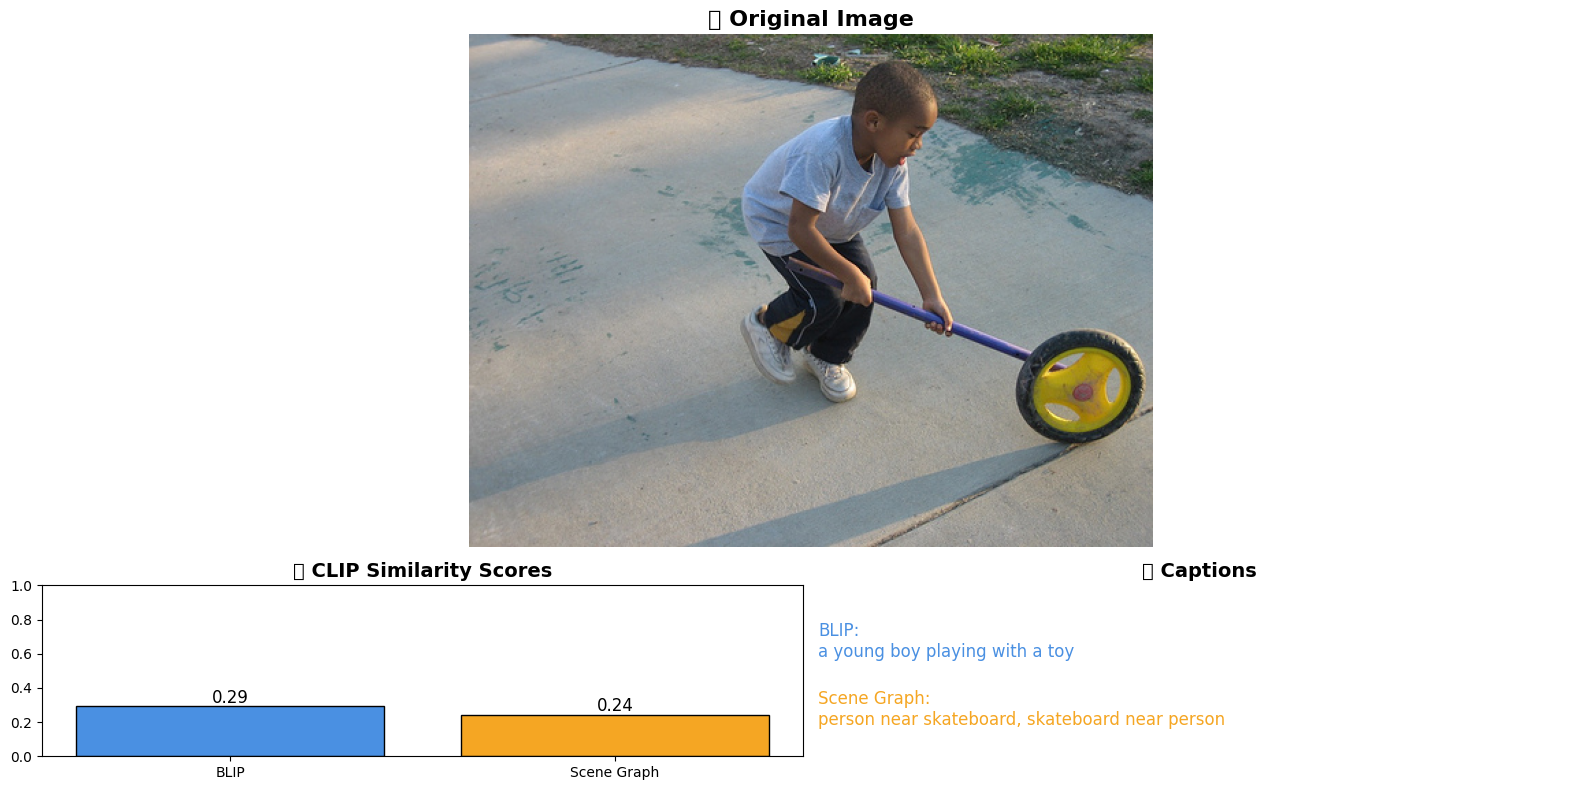


--- 2066271441.jpg ---

image 1/1 d:\Project\Making\SIRE-Mini-Project\notebooks\..\datasets\mini-test-dataset\Images\2066271441.jpg: 640x544 1 dog, 1 frisbee, 94.8ms
Speed: 4.1ms preprocess, 94.8ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 544)


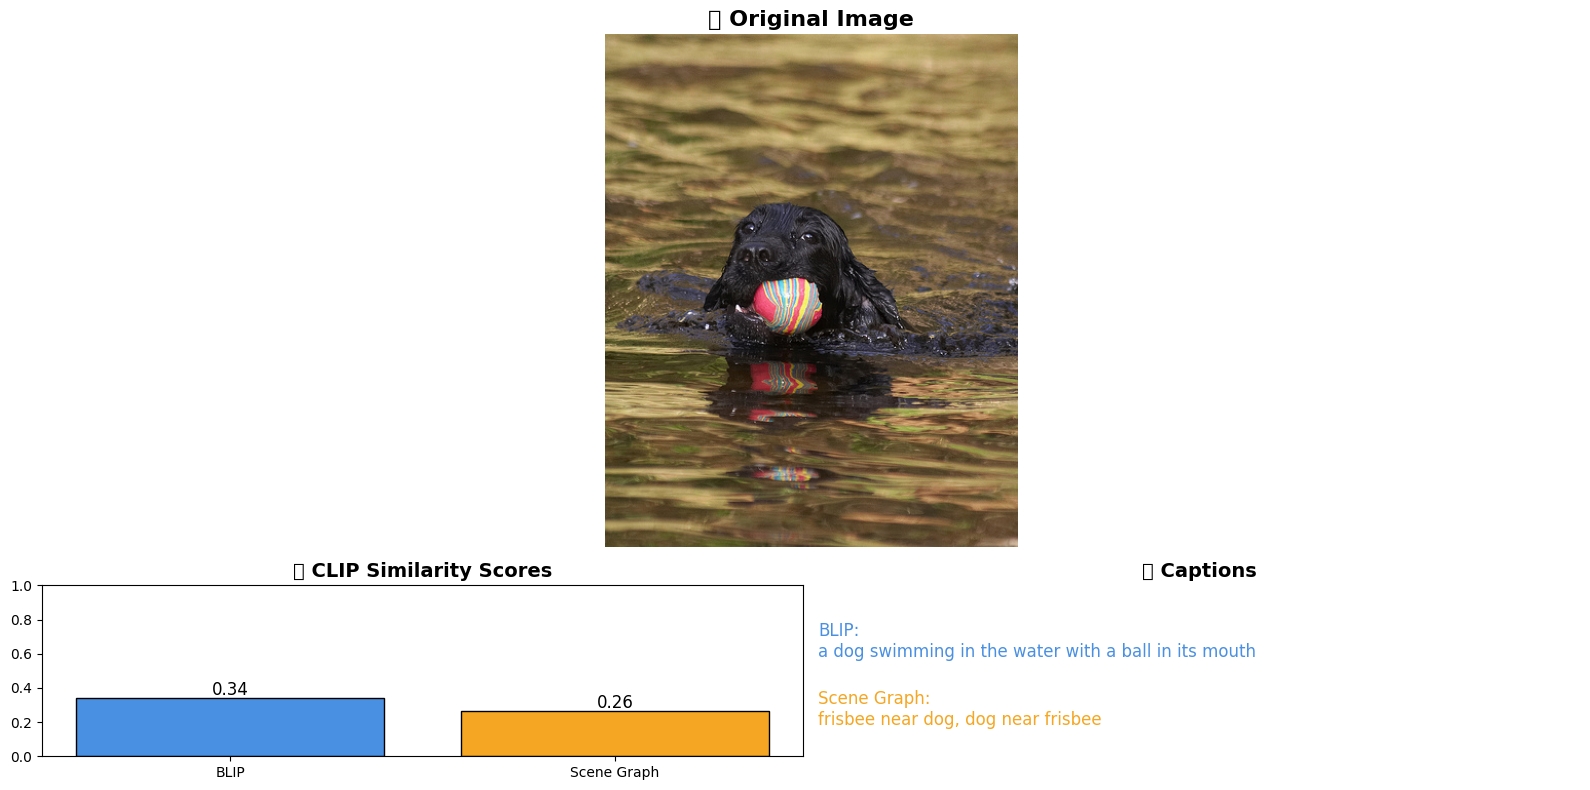


--- 2256091090.jpg ---

image 1/1 d:\Project\Making\SIRE-Mini-Project\notebooks\..\datasets\mini-test-dataset\Images\2256091090.jpg: 448x640 2 persons, 1 dog, 1 tv, 80.5ms
Speed: 1.8ms preprocess, 80.5ms inference, 2.0ms postprocess per image at shape (1, 3, 448, 640)


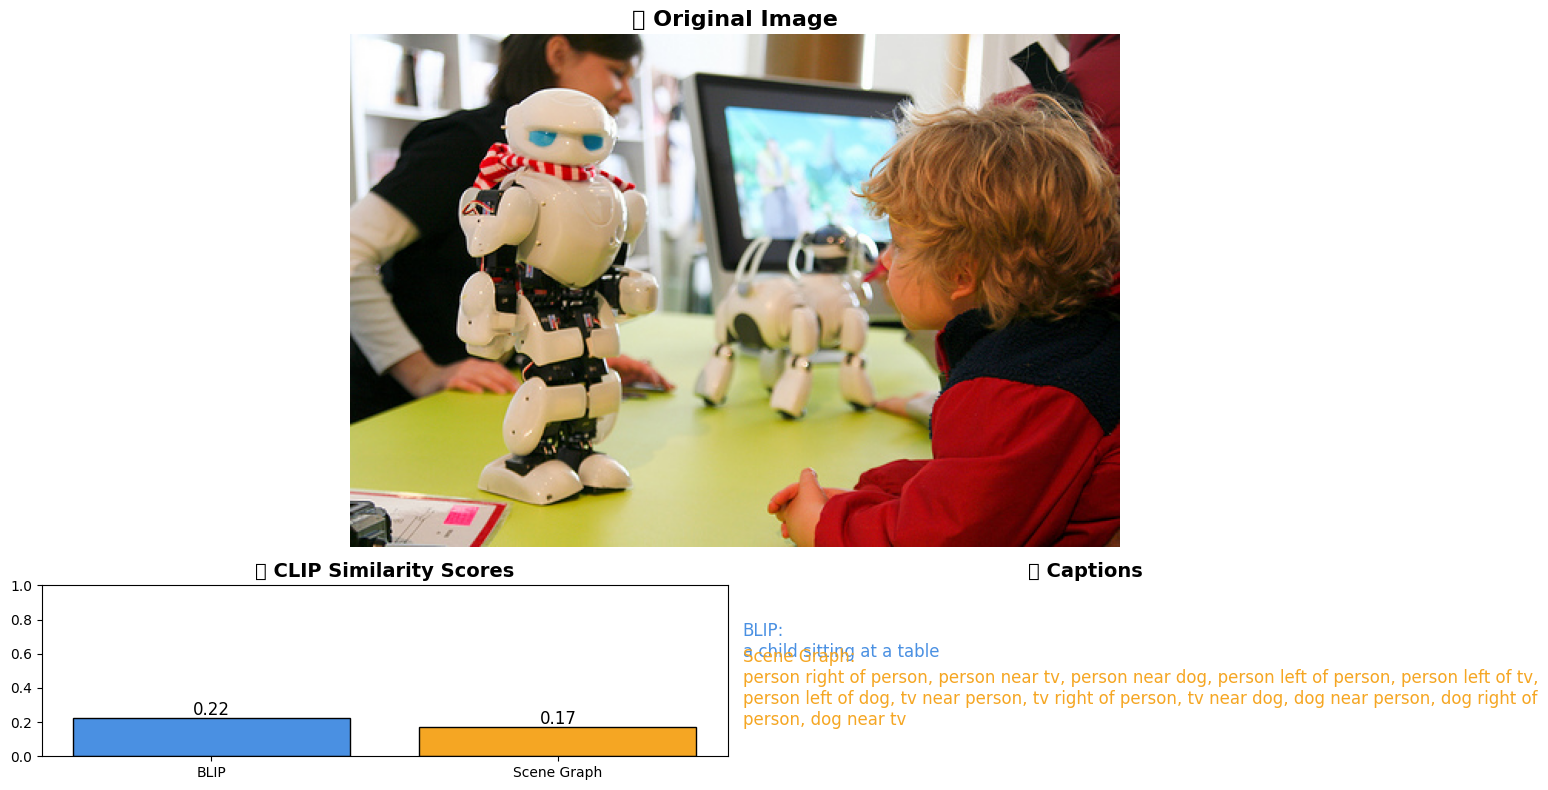


--- 2620517927.jpg ---

image 1/1 d:\Project\Making\SIRE-Mini-Project\notebooks\..\datasets\mini-test-dataset\Images\2620517927.jpg: 640x448 6 persons, 1 bicycle, 4 cars, 5 motorcycles, 1 truck, 100.1ms
Speed: 2.1ms preprocess, 100.1ms inference, 3.3ms postprocess per image at shape (1, 3, 640, 448)


C:\Users\harsh\AppData\Local\Temp\ipykernel_20784\4286099111.py:59: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


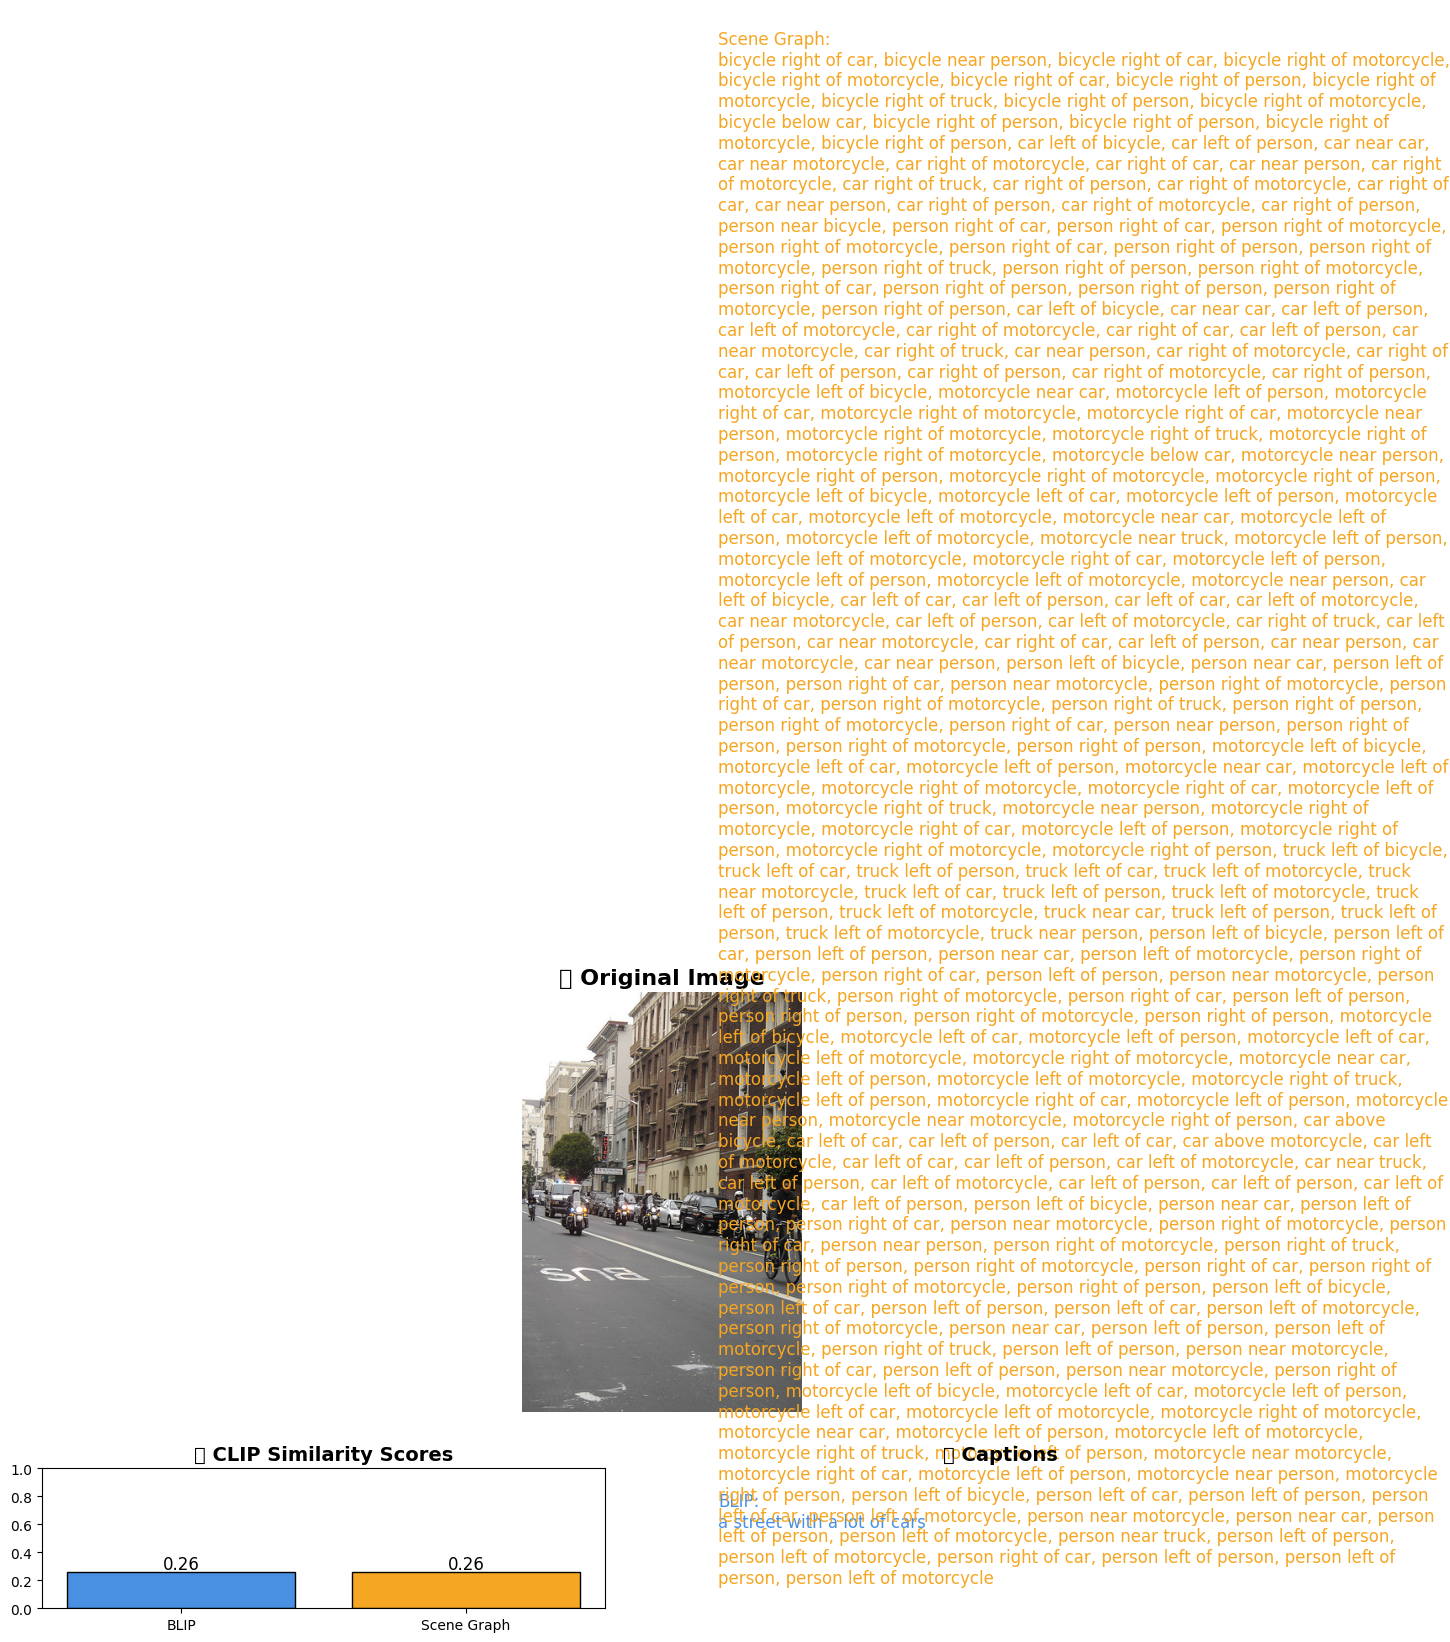

In [28]:
# 🔁 Step 4: Run on All Images

image_folder = "../datasets/mini-test-dataset/Images"
for filename in os.listdir(image_folder):
    if filename.endswith(".jpg"):
        print(f"\n--- {filename} ---")
        visualize_comparison(os.path.join(image_folder, filename))

# ✅ Bonus Ideas

- Add **BLIP + Scene Graph fusion**: concatenate both captions and test similarity.
- Store results in a table (Pandas DataFrame) for analysis.
- Add **FAISS indexing** to test retrieval across multiple images.

Would you like me to help you build a retrieval UI or add caption fusion logic next?